In [1]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

In [2]:
data_log2 = pd.read_pickle('data_log2_Lisbon.pkl')

In [3]:
data_log2

Protein.Group,A0A0A0MS15,A0A0C4DH38,O00391,O00533,O14498,O14594,O14773,O15394,O43505,O75144,...,Q9P2S2,Q9UBP4,Q9UBX1,Q9UBX5,Q9UGM5,Q9UHL4,Q9ULB1,Q9Y4C0,Q9Y646,Q9Y6R7
LIS090,8.008485,7.884580,7.046524,9.502615,6.808836,6.264486,6.706240,8.666203,11.235021,10.433533,...,8.163801,11.983824,7.474387,7.673846,6.288357,6.569209,8.519585,8.721916,6.428503,9.765251
LIS098,8.408618,8.316675,6.742249,9.214086,6.607503,5.651112,6.832662,8.234889,11.566791,10.476068,...,7.954033,11.609941,7.249929,7.780402,6.187722,6.248402,8.200359,8.767165,6.877487,8.354624
LIS017,6.710379,7.121647,6.803782,9.288289,6.816740,6.544420,6.978630,8.426206,11.710423,9.890181,...,8.006769,11.674201,7.640505,8.166806,5.968895,6.599523,8.233011,8.527669,7.343052,7.835937
LIS007,10.421655,9.388187,7.020158,8.407935,7.345618,4.951625,6.082505,8.008798,10.026012,11.312299,...,6.808102,10.691421,7.316173,7.842388,7.781714,6.443365,6.264730,7.430227,6.817291,9.228949
LIS026,8.605772,8.765760,7.234664,9.194671,6.489169,6.035030,6.804389,8.621330,11.018047,10.837123,...,7.335810,11.564264,7.439665,8.143383,7.001780,6.322777,8.011177,8.391046,6.702228,8.845537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LIS102,8.583207,7.473089,7.144108,9.710235,7.141964,7.286142,6.577400,8.624346,12.354748,9.557963,...,8.412790,11.306529,7.106997,7.976610,6.025791,6.078200,8.961421,9.106806,6.697260,9.566731
LIS103,8.504410,9.427137,6.745062,8.539744,7.318733,5.619750,6.116679,8.008053,11.802823,9.665352,...,7.313518,10.799476,7.207493,7.716394,6.032231,5.496488,8.011059,8.241826,6.325904,10.136773
LIS104,8.838303,8.791313,7.131044,8.249825,6.895412,6.168939,6.442655,8.151280,11.133271,9.921353,...,7.347630,10.902805,7.470407,7.936497,6.393099,6.199994,7.690033,7.994908,6.444203,10.341875
LIS116,10.749107,8.583583,7.019946,7.900897,6.739943,5.874352,6.118279,8.195874,11.042596,9.845702,...,6.489773,10.191849,7.128634,8.297292,6.040358,5.941968,6.786884,7.390092,6.811073,10.435931


In [4]:
import pickle

with open('list_groups_2.pkl', 'rb') as f:
    list_groups = pickle.load(f)

print(len(list_groups))

68


In [5]:
list_groups = pd.Series(list_groups)

In [6]:
def calculate_vip(pls, X):
    
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_
    
    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    
    Wnorm = (w ** 2) / np.sum(w ** 2, axis=0)
    
    vip = np.sqrt(p * (Wnorm @ s) / np.sum(s))
    
    return vip.flatten()

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder

# ======================
# DATA LOADING
# ======================
X = data_log2
y = np.array(list_groups)

# ======================
# GLOBAL PARAMETERS
# ======================
vip_thresholds = [0.1, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
decision_thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

n_iterations = 50  
n_seeds = 15       

all_test_mcc = []
all_test_auc = []
all_n_features = []
all_best_vip_thr = []
all_best_dec_thr = []
global_stable_counts = pd.Series(0, index=X.columns)

def stratified_bootstrap(X, y):
    ad_idx = np.where(y == "MCI-AD")[0]
    ct_idx = np.where(y == "MCI-CT")[0]
    ad_sample = np.random.choice(ad_idx, size=len(ad_idx), replace=True)
    ct_sample = np.random.choice(ct_idx, size=len(ct_idx), replace=True)
    indices = np.concatenate([ad_sample, ct_sample])
    np.random.shuffle(indices)
    return X.iloc[indices], y[indices]

# ======================
# MAIN SEED LOOP
# ======================
for seed in range(n_seeds):
    print(f"\n" + "="*40)
    print(f"RUNNING SEED {seed}")
    print("="*40)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=seed
    )

    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=seed)
    le = LabelEncoder()
    le.fit(y_train)
    y_train_enc = le.transform(y_train)
    y_test_enc = le.transform(y_test)

    # Griglia per ottimizzazione incrociata (VIP x Decision)
    grid_mcc = np.zeros((len(vip_thresholds), len(decision_thresholds)))
    grid_auc = np.zeros(len(vip_thresholds))

    for v_idx, v_thr in enumerate(vip_thresholds):
        fold_mccs = []
        fold_aucs = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_sub, y_sub = X_train.iloc[train_idx], y_train[train_idx]
            X_val, y_val = X_train.iloc[val_idx], y_train[val_idx]
            y_val_enc = le.transform(y_val)

            # --- Feature Selection (VIP Stability) ---
            vip_matrix = np.zeros((n_iterations, X_sub.shape[1]))
            for i in range(n_iterations):
                X_b, y_b = stratified_bootstrap(X_sub, y_sub)
                pls_b = PLSRegression(n_components=2)
                pls_b.fit(X_b, le.transform(y_b))
                vip_matrix[i] = (calculate_vip(pls_b, X_b) > 1).astype(int)

            vip_freq = vip_matrix.mean(axis=0)
            sel_feats = X_sub.columns[vip_freq >= v_thr]
            if len(sel_feats) == 0: sel_feats = [X_sub.columns[np.argmax(vip_freq)]]

            # --- Validation ---
            pls_cv = PLSRegression(n_components=2)
            pls_cv.fit(X_sub[sel_feats], le.transform(y_sub))
            y_prob_val = pls_cv.predict(X_val[sel_feats]).ravel()

            mccs_per_dec = [matthews_corrcoef(y_val_enc, (y_prob_val > d_thr).astype(int)) for d_thr in decision_thresholds]
            fold_mccs.append(mccs_per_dec)
            fold_aucs.append(roc_auc_score(y_val_enc, y_prob_val))

        grid_mcc[v_idx, :] = np.mean(fold_mccs, axis=0)
        grid_auc[v_idx] = np.mean(fold_aucs)

    # Identificazione best combination
    best_v_idx, best_d_idx = np.unravel_index(np.argmax(grid_mcc), grid_mcc.shape)
    best_v_thr = vip_thresholds[best_v_idx]
    best_d_thr = decision_thresholds[best_d_idx]

    # --- Training Finale (Full X_train) ---
    final_vip_matrix = np.zeros((n_iterations, X_train.shape[1]))
    for i in range(n_iterations):
        X_b, y_b = stratified_bootstrap(X_train, y_train)
        pls_b = PLSRegression(n_components=2).fit(X_b, le.transform(y_b))
        final_vip_matrix[i] = (calculate_vip(pls_b, X_b) > 1).astype(int)
    
    final_vip_freq = final_vip_matrix.mean(axis=0)
    top_features = X_train.columns[final_vip_freq >= best_v_thr]
    if len(top_features) == 0: top_features = [X_train.columns[np.argmax(final_vip_freq)]]

    global_stable_counts.loc[top_features] += 1

    # --- Test Finale (X_test) ---
    pls_final = PLSRegression(n_components=2).fit(X_train[top_features], y_train_enc)
    y_prob_test = pls_final.predict(X_test[top_features]).ravel()
    
    test_mcc = matthews_corrcoef(y_test_enc, (y_prob_test > best_d_thr).astype(int))
    test_auc = roc_auc_score(y_test_enc, y_prob_test)

    all_test_mcc.append(test_mcc)
    all_test_auc.append(test_auc)
    all_n_features.append(len(top_features))
    all_best_vip_thr.append(best_v_thr)
    all_best_dec_thr.append(best_d_thr)

    print(f"Seed {seed}: MCC={test_mcc:.3f}, AUC={test_auc:.3f}, Features={len(top_features)}")

# ======================
# FINAL PERFORMANCE SUMMARY
# ======================
print("\n" + "="*50)
print("FINAL CONSOLIDATED RESULTS (30 SEEDS)")
print("="*50)
print(f"Mean MCC: {np.mean(all_test_mcc):.4f} (±{np.std(all_test_mcc):.4f})")
print(f"Mean AUC: {np.mean(all_test_auc):.4f} (±{np.std(all_test_auc):.4f})")
print(f"Mean Features: {np.mean(all_n_features):.2f} (±{np.std(all_n_features):.2f})")

print("\n--- TOP 30 MOST STABLE PROTEINS ACROSS SEEDS ---")
global_stability = (global_stable_counts / n_seeds).sort_values(ascending=False)
print(global_stability)

print("\n--- FREQUENCY OF SELECTED VIP THRESHOLDS (Stability) ---")
print(pd.Series(all_best_vip_thr).value_counts(normalize=True).sort_index())

# ======================
# BUILD RESULT TABLE (PLS-DA)
# ======================
df_plsda = pd.DataFrame({
    "model": "PLS-DA",
    "seed": list(range(n_seeds)),
    "mcc": all_test_mcc,
    "auc": all_test_auc,
    "n_features": all_n_features,
    "best_vip_threshold": all_best_vip_thr,
    "best_decision_threshold": all_best_dec_thr
})

print("\n--- PLS-DA RESULTS TABLE ---")
print(df_plsda.head())

print("\n--- FREQUENCY OF SELECTED DECISION THRESHOLDS (Classification) ---")
print(pd.Series(all_best_dec_thr).value_counts(normalize=True).sort_index())


RUNNING SEED 0
Seed 0: MCC=0.742, AUC=0.959, Features=36

RUNNING SEED 1
Seed 1: MCC=0.786, AUC=0.980, Features=31

RUNNING SEED 2
Seed 2: MCC=1.000, AUC=1.000, Features=35

RUNNING SEED 3
Seed 3: MCC=0.901, AUC=0.959, Features=183

RUNNING SEED 4
Seed 4: MCC=0.816, AUC=0.959, Features=66

RUNNING SEED 5
Seed 5: MCC=1.000, AUC=1.000, Features=44

RUNNING SEED 6
Seed 6: MCC=0.901, AUC=1.000, Features=54

RUNNING SEED 7
Seed 7: MCC=1.000, AUC=1.000, Features=175

RUNNING SEED 8
Seed 8: MCC=1.000, AUC=1.000, Features=171

RUNNING SEED 9
Seed 9: MCC=0.901, AUC=0.959, Features=42

RUNNING SEED 10
Seed 10: MCC=0.901, AUC=0.959, Features=63

RUNNING SEED 11
Seed 11: MCC=0.901, AUC=1.000, Features=74

RUNNING SEED 12
Seed 12: MCC=0.612, AUC=0.888, Features=85

RUNNING SEED 13
Seed 13: MCC=1.000, AUC=1.000, Features=55

RUNNING SEED 14
Seed 14: MCC=1.000, AUC=1.000, Features=68

FINAL CONSOLIDATED RESULTS (30 SEEDS)
Mean MCC: 0.8975 (±0.1119)
Mean AUC: 0.9776 (±0.0303)
Mean Features: 78.80 (±5

In [8]:
print(len(global_stability))
global_stability.to_pickle('global_stable_counts_Lisbon.pkl')
df_plsda.to_pickle('df_plsda_Lisbon.pkl')

226


In [9]:
df_plsda

,model,seed,mcc,auc,n_features,best_vip_threshold,best_decision_threshold
0,PLS-DA,0,0.741620,0.959184,36,0.8,0.40
1,PLS-DA,1,0.785714,0.979592,31,0.9,0.60
2,PLS-DA,2,1.000000,1.000000,35,0.8,0.40
3,PLS-DA,3,0.901388,0.959184,183,0.1,0.45
4,PLS-DA,4,0.816497,0.959184,66,0.6,0.45
5,PLS-DA,5,1.000000,1.000000,44,0.7,0.50
6,PLS-DA,6,0.901388,1.000000,54,0.6,0.40
7,PLS-DA,7,1.000000,1.000000,175,0.1,0.40
8,PLS-DA,8,1.000000,1.000000,171,0.1,0.50
9,PLS-DA,9,0.901388,0.959184,42,0.7,0.40


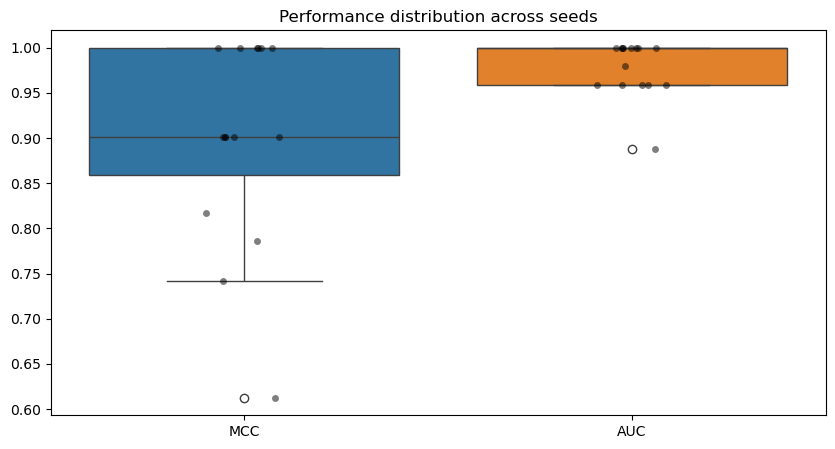

In [10]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=[all_test_mcc, all_test_auc])
sns.stripplot(data=[all_test_mcc, all_test_auc], color='black', alpha=0.5)
plt.xticks([0,1], ['MCC', 'AUC'])
plt.title("Performance distribution across seeds")
plt.show()

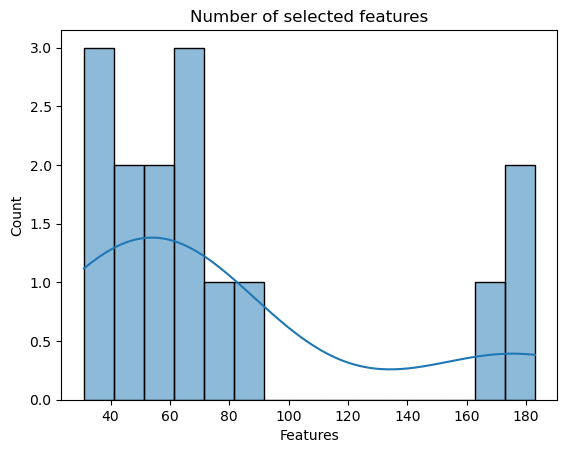

In [11]:
plt.figure()
sns.histplot(all_n_features, bins=15, kde=True)
plt.title("Number of selected features")
plt.xlabel("Features")
plt.show()

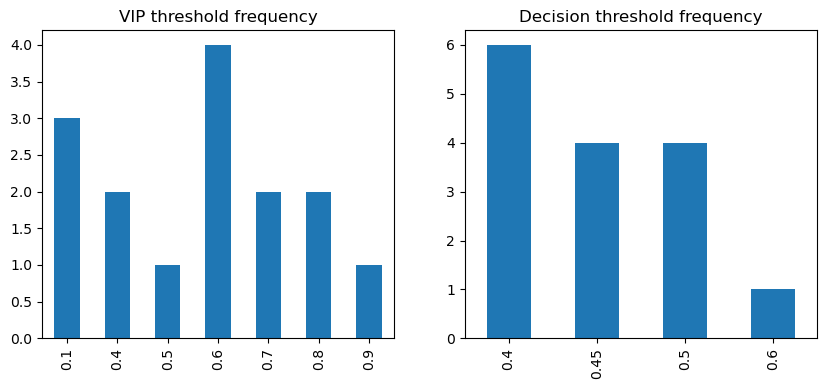

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
pd.Series(all_best_vip_thr).value_counts().sort_index().plot(kind='bar')
plt.title("VIP threshold frequency")

plt.subplot(1,2,2)
pd.Series(all_best_dec_thr).value_counts().sort_index().plot(kind='bar')
plt.title("Decision threshold frequency")

plt.show()